# Optimización de hiperparámetros (HPO): los fundamentos

**Objetivo de la sesión:** entender *qué* es un hiperparámetro, *por qué* hay que buscarlo de forma sistemática y *cómo* funcionan las cuatro estrategias de búsqueda más usadas:

| # | Estrategia | Idea en una frase | Herramienta |
|---|---|---|---|
| 1 | **Grid search** | Probar todas las combinaciones de una rejilla | `GridSearchCV` |
| 2 | **Random search** | Probar combinaciones al azar | `RandomizedSearchCV` |
| 3 | **Successive halving** | Un torneo: muchos candidatos con pocos datos, pocos candidatos con todos los datos | `HalvingRandomSearchCV` |
| 4 | **Optimización bayesiana** | Aprender de los intentos anteriores para elegir el siguiente | `optuna` |

> Basado en la sección 6.3 *Optimizing hyperparameters* (Grid search, random search, successive halving, Bayesian con Optuna y ajuste manual).

**Duración estimada de ejecución:** 2–4 minutos en un portátil o en Google Colab. Todo corre sin descargar datos.

## 0. Preparación

Solo necesitamos `scikit-learn`, `matplotlib`, `pandas` y `optuna`. La siguiente celda instala Optuna si no está disponible (por ejemplo, en Colab).

In [2]:
import sys, subprocess
try:
    import optuna
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "optuna"], check=True)
    import optuna

import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import loguniform, randint, uniform

import sklearn
from sklearn.datasets import make_classification
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_val_score,
                                     validation_curve, GridSearchCV, RandomizedSearchCV)
from sklearn.experimental import enable_halving_search_cv  # noqa: F401 (activa HalvingRandomSearchCV)
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
SEED = 42

# Estilo sobrio para las gráficas
plt.rcParams.update({
    "figure.figsize": (8, 4.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.titleweight": "bold", "axes.titlesize": 12, "font.size": 10,
    "lines.linewidth": 2, "axes.axisbelow": True,
})
AZUL, NARANJA, AGUAMARINA, AMARILLO, VIOLETA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#4a3aa7"
GRIS = "#8a8984"

print("scikit-learn", sklearn.__version__, "| optuna", optuna.__version__)

scikit-learn 1.9.1 | optuna 5.0.0


### Los datos

Usamos un problema de **clasificación binaria sintético** (3 000 filas, 30 variables, de las cuales solo 5 son realmente informativas y con 10 % de etiquetas ruidosas). Es un escenario realista: muchas columnas, poca señal y ruido.

**Regla de oro desde el principio:** separamos un **conjunto de prueba (test)** que *no se toca* durante la búsqueda. Solo lo usamos al final para medir el modelo elegido.

In [3]:
X, y = make_classification(n_samples=3000, n_features=30, n_informative=5, n_redundant=5,
                           flip_y=0.10, class_sep=0.7, random_state=SEED)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print(f"Entrenamiento: {X_train.shape}  |  Prueba (guardado bajo llave): {X_test.shape}")
print(f"Proporción de la clase 1: {y.mean():.2f}")

Entrenamiento: (2400, 30)  |  Prueba (guardado bajo llave): (600, 30)
Proporción de la clase 1: 0.50


---
## 1. ¿Qué es un hiperparámetro?

| | **Parámetro** | **Hiperparámetro** |
|---|---|---|
| ¿Quién lo define? | El algoritmo lo **aprende** de los datos | Nosotros lo **fijamos antes** de entrenar |
| Ejemplos | Coeficientes de una regresión, umbrales de corte de un árbol | `max_depth` de un árbol, `C` en regresión logística, `learning_rate` en boosting |
| ¿Cómo se obtiene? | `.fit()` | **Búsqueda** (HPO) |

Los hiperparámetros son las "perillas" que controlan **qué tan flexible** es el modelo, es decir, qué forma funcional puede aprender. Los valores por defecto sirven como punto de partida, pero no están hechos para *su* problema.

### Experimento: una sola perilla, `max_depth` de un árbol de decisión

Medimos la exactitud (*accuracy*) en entrenamiento y en validación cruzada para distintas profundidades.

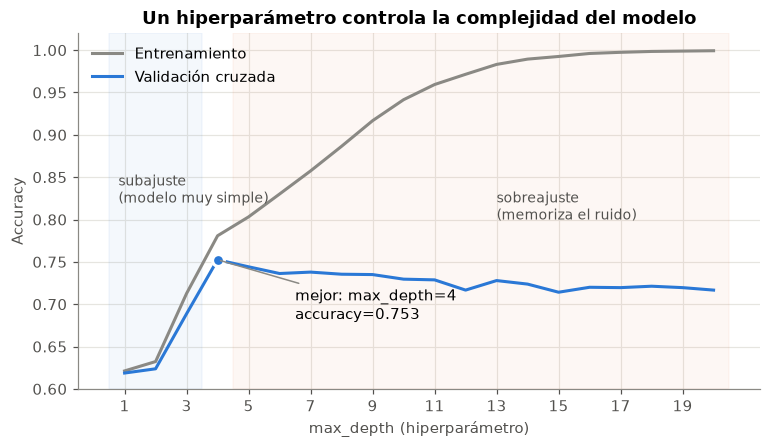

In [4]:
profundidades = np.arange(1, 21)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

train_sc, val_sc = validation_curve(
    DecisionTreeClassifier(random_state=0), X_train, y_train,
    param_name="max_depth", param_range=profundidades, cv=cv5, scoring="accuracy", n_jobs=-1)

tr, va = train_sc.mean(axis=1), val_sc.mean(axis=1)
mejor = profundidades[va.argmax()]

fig, ax = plt.subplots()
ax.plot(profundidades, tr, color=GRIS, label="Entrenamiento")
ax.plot(profundidades, va, color=AZUL, label="Validación cruzada")
ax.scatter([mejor], [va.max()], s=60, color=AZUL, zorder=3, edgecolor="white", linewidth=2)
ax.annotate(f"mejor: max_depth={mejor}\naccuracy={va.max():.3f}", (mejor, va.max()),
            xytext=(mejor + 2.5, va.max() - 0.07), arrowprops=dict(arrowstyle="-", color=GRIS))
ax.axvspan(0.5, mejor - 0.5, color=AZUL, alpha=0.05); ax.axvspan(mejor + 0.5, 20.5, color=NARANJA, alpha=0.05)
ax.text(0.8, 0.82, "subajuste\n(modelo muy simple)", color="#52514e", fontsize=9)
ax.text(13, 0.80, "sobreajuste\n(memoriza el ruido)", color="#52514e", fontsize=9)
ax.set(xlabel="max_depth (hiperparámetro)", ylabel="Accuracy", title="Un hiperparámetro controla la complejidad del modelo",
       ylim=(0.6, 1.02), xticks=profundidades[::2])
ax.legend(loc="upper left", frameon=False)
plt.show()

**Qué observar**

* El error de **entrenamiento** siempre mejora con más profundidad: no sirve para elegir.
* La curva de **validación** sube, llega a un máximo y luego baja → sobreajuste.
* El mejor valor **depende de los datos**; no hay forma de saberlo sin probar.

**Problema:** aquí movimos *una* perilla. Un gradient boosting tiene 5–10 perillas relevantes que además **interactúan** entre sí. Necesitamos un método sistemático.

---
## 2. La receta sistemática de HPO

Antes de elegir un algoritmo de búsqueda, definimos tres cosas:

1. **Una métrica de evaluación** → aquí, `accuracy`.
2. **Un espacio de búsqueda** → qué hiperparámetros exploramos y en qué rangos.
3. **Un esquema de validación cruzada** → para que el "mejor" valor generalice y no sea suerte de una partición.

Y después:

4. **Una estrategia de búsqueda** → cómo recorremos el espacio gastando el menor cómputo posible.

```
          ┌───────────────── bucle de búsqueda ─────────────────┐
espacio → │ proponer configuración → validación cruzada → score │ → mejor configuración → evaluar UNA vez en test
          └─────────────────────────────────────────────────────┘
```

### Detalle práctico: hiperparámetros dentro de un `Pipeline`

Cuando el modelo va dentro de un `Pipeline` (lo correcto, para que el preprocesamiento se ajuste solo con los datos de cada *fold* y no haya fuga de información), cada hiperparámetro se nombra así:

**`<nombre_del_paso>__<nombre_del_hiperparámetro>`** (dos guiones bajos)

In [7]:
pipe_lr = Pipeline([
    ("escalado", StandardScaler()),
    ("modelo", LogisticRegression(solver="saga", max_iter=5000)),
])

# Así se ven los nombres que usaremos en el espacio de búsqueda:
[k for k in pipe_lr.get_params() if k.startswith("modelo__") and k.split("__")[1] in ("C", "l1_ratio")]

['modelo__C', 'modelo__l1_ratio']

---
## 3. Estrategia 1 — Grid search (búsqueda en rejilla)

Para cada hiperparámetro elegimos una lista de valores y probamos **todas** las combinaciones.

Ejemplo con regresión logística regularizada:
* `C` (inverso de la fuerza de regularización): 8 valores en escala logarítmica, de 0.001 a 100.
* `l1_ratio`: 0 = Ridge (L2), 0.5 = Elastic Net, 1 = Lasso (L1).

Total: 8 × 3 = **24 combinaciones × 5 folds = 120 entrenamientos**.

In [8]:
grid_lr = {
    "modelo__C": np.logspace(-3, 2, 8),
    "modelo__l1_ratio": [0.0, 0.5, 1.0],
}

t0 = time.perf_counter()
gs_lr = GridSearchCV(pipe_lr, grid_lr, scoring="accuracy", cv=cv5, n_jobs=-1)
gs_lr.fit(X_train, y_train)
print(f"Entrenamientos realizados: {len(gs_lr.cv_results_['params']) * cv5.get_n_splits()}  "
      f"| tiempo: {time.perf_counter() - t0:.1f} s")
print("Mejores hiperparámetros:", gs_lr.best_params_)
print(f"Mejor accuracy (CV): {gs_lr.best_score_:.4f}")

Entrenamientos realizados: 120  | tiempo: 2.8 s
Mejores hiperparámetros: {'modelo__C': np.float64(0.02682695795279726), 'modelo__l1_ratio': 1.0}
Mejor accuracy (CV): 0.6517


Como solo hay dos hiperparámetros, podemos **ver** toda la superficie de resultados.

> Noten que el mejor accuracy es bajo (~0.65): la regresión logística es un modelo lineal y estos datos no lo son. **Ningún ajuste de hiperparámetros compensa elegir una familia de modelos que no puede capturar el patrón.** Primero se elige un buen modelo; luego se afina.

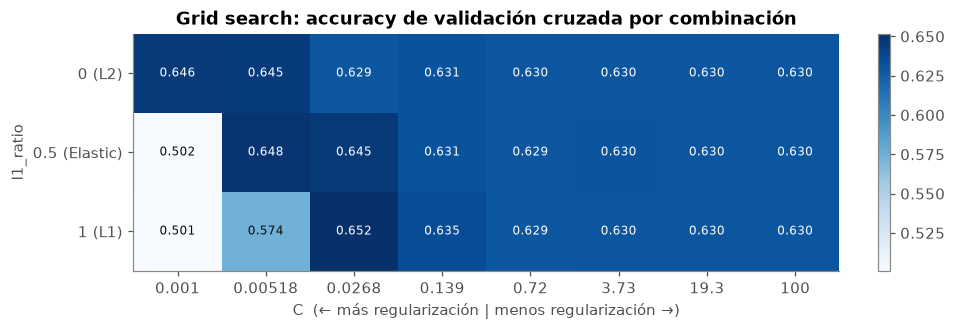

In [9]:
res = pd.DataFrame(gs_lr.cv_results_)
tabla = res.pivot(index="param_modelo__l1_ratio", columns="param_modelo__C", values="mean_test_score")

fig, ax = plt.subplots(figsize=(9, 2.8))
im = ax.imshow(tabla.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(tabla.shape[1]), [f"{c:.3g}" for c in tabla.columns])
ax.set_yticks(range(tabla.shape[0]), ["0 (L2)", "0.5 (Elastic)", "1 (L1)"])
for i in range(tabla.shape[0]):
    for j in range(tabla.shape[1]):
        v = tabla.values[i, j]
        ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=8,
                color="white" if v > tabla.values.mean() else "#0b0b0b")
ax.set(xlabel="C  (← más regularización | menos regularización →)", ylabel="l1_ratio",
       title="Grid search: accuracy de validación cruzada por combinación")
ax.grid(False)
plt.colorbar(im, ax=ax, fraction=0.03)
plt.show()

### Ventajas y límites del grid search

✅ Simple, exhaustivo, fácil de paralelizar y de interpretar. Ideal para **modelos lineales**: pocos hiperparámetros y en su mayoría discretos.

❌ **Explosión combinatoria.** El costo se multiplica con cada hiperparámetro que agregamos:

In [7]:
valores_por_hp = 5
for n_hp in range(1, 8):
    combos = valores_por_hp ** n_hp
    print(f"{n_hp} hiperparámetros × {valores_por_hp} valores = {combos:>7,} combinaciones  →  {combos * 5:>7,} entrenamientos con CV de 5 folds")

1 hiperparámetros × 5 valores =       5 combinaciones  →       25 entrenamientos con CV de 5 folds
2 hiperparámetros × 5 valores =      25 combinaciones  →      125 entrenamientos con CV de 5 folds
3 hiperparámetros × 5 valores =     125 combinaciones  →      625 entrenamientos con CV de 5 folds
4 hiperparámetros × 5 valores =     625 combinaciones  →    3,125 entrenamientos con CV de 5 folds
5 hiperparámetros × 5 valores =   3,125 combinaciones  →   15,625 entrenamientos con CV de 5 folds
6 hiperparámetros × 5 valores =  15,625 combinaciones  →   78,125 entrenamientos con CV de 5 folds
7 hiperparámetros × 5 valores =  78,125 combinaciones  →  390,625 entrenamientos con CV de 5 folds


❌ Hay que **discretizar** los hiperparámetros continuos (¿qué valores de `learning_rate` ponemos en la rejilla?).

❌ Si un hiperparámetro **no importa**, desperdiciamos cómputo repitiendo los mismos valores del que sí importa. Esto nos lleva a la siguiente estrategia.


---
## 4. Estrategia 2 — Random search (búsqueda aleatoria)

En lugar de una rejilla, **muestreamos combinaciones al azar** de distribuciones que definimos para cada hiperparámetro.

### La intuición (Bergstra & Bengio, 2012)

Con el mismo presupuesto de 9 intentos, la rejilla prueba solo **3 valores distintos** de cada hiperparámetro; la búsqueda aleatoria prueba **9 valores distintos** de cada uno. Si solo uno importa, el azar lo explora mucho mejor.

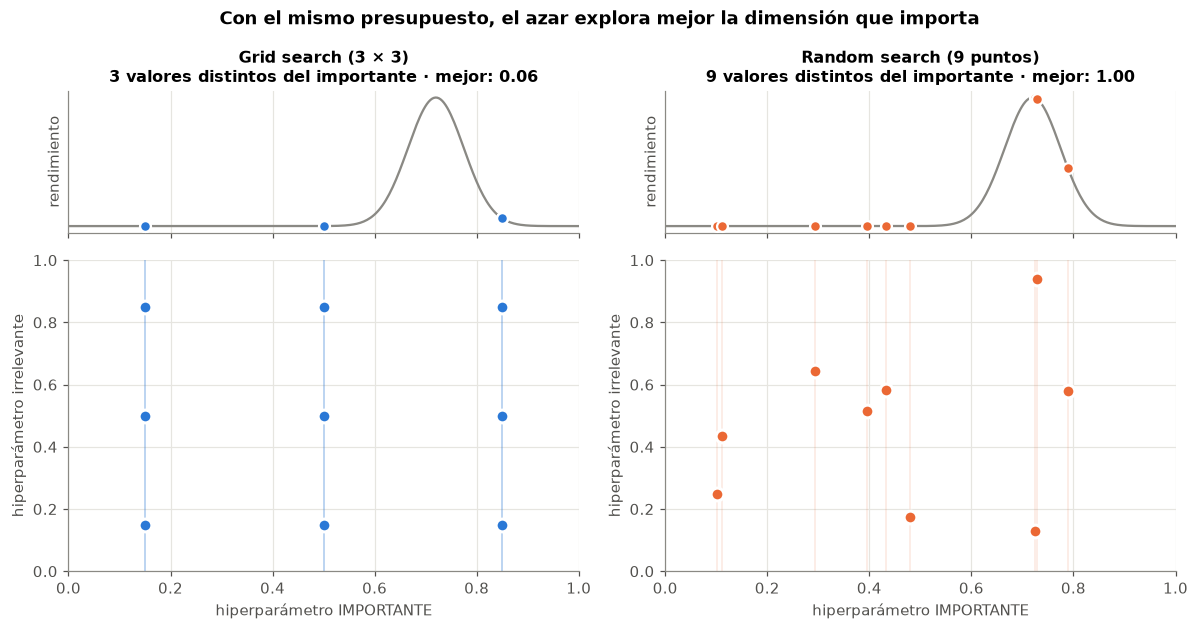

In [10]:
def f_importante(x):  # el rendimiento depende solo de x; y es irrelevante
    return np.exp(-((x - 0.72) ** 2) / 0.006)

rng = np.random.default_rng(3)
g = np.array([0.15, 0.5, 0.85])
grid_pts = np.array([(a, b) for a in g for b in g])
rand_pts = rng.uniform(0.02, 0.98, size=(9, 2))
xs = np.linspace(0, 1, 300)

fig, axes = plt.subplots(2, 2, figsize=(11, 5.8), gridspec_kw={"height_ratios": [1, 2.2]}, sharex=True)
for col, (pts, nombre, color) in enumerate([(grid_pts, "Grid search (3 × 3)", AZUL),
                                            (rand_pts, "Random search (9 puntos)", NARANJA)]):
    top, bot = axes[0, col], axes[1, col]
    top.plot(xs, f_importante(xs), color=GRIS, lw=1.5)
    top.scatter(pts[:, 0], f_importante(pts[:, 0]), color=color, s=50, zorder=3, edgecolor="white", linewidth=1.5)
    n_dist = len(np.unique(pts[:, 0].round(4)))
    top.set(title=f"{nombre}\n{n_dist} valores distintos del importante · mejor: {f_importante(pts[:, 0]).max():.2f}",
            yticks=[], ylabel="rendimiento")
    top.title.set_fontsize(10.5)
    bot.scatter(pts[:, 0], pts[:, 1], color=color, s=70, edgecolor="white", linewidth=2, zorder=3)
    for x in pts[:, 0]:
        bot.axvline(x, color=color, alpha=0.15, lw=1)
    bot.set(xlabel="hiperparámetro IMPORTANTE", ylabel="hiperparámetro irrelevante", xlim=(0, 1), ylim=(0, 1))
fig.suptitle("Con el mismo presupuesto, el azar explora mejor la dimensión que importa", fontweight="bold")
plt.tight_layout(); plt.show()

### Random search sobre un modelo de *boosting*

Ahora pasamos a un modelo con muchas perillas: `HistGradientBoostingClassifier` (la implementación de gradient boosting de scikit-learn, inspirada en LightGBM). Las mismas ideas aplican a XGBoost o LightGBM.

Primero, **la línea base**: ¿qué tan bien le va con los valores por defecto?

In [11]:
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
PRESUPUESTO = 30  # número de configuraciones que cada estrategia puede evaluar

base = HistGradientBoostingClassifier(early_stopping=False, random_state=0)
t0 = time.perf_counter()
score_base = cross_val_score(base, X_train, y_train, cv=cv3, scoring="accuracy", n_jobs=-1).mean()
print(f"Línea base (valores por defecto): accuracy CV = {score_base:.4f}   ({time.perf_counter() - t0:.1f} s)")

Línea base (valores por defecto): accuracy CV = 0.7946   (0.3 s)


In [12]:
espacio_random = {
    "learning_rate":     loguniform(0.005, 1.0),   # escala log
    "max_iter":          randint(50, 400),         # número de árboles
    "max_leaf_nodes":    randint(4, 128),          # tamaño de cada árbol
    "min_samples_leaf":  randint(5, 100),          # regularización por hoja
    "l2_regularization": loguniform(1e-6, 10),     # escala log
}

t0 = time.perf_counter()
rs = RandomizedSearchCV(base, espacio_random, n_iter=PRESUPUESTO, scoring="accuracy",
                        cv=cv3, n_jobs=-1, random_state=SEED)
rs.fit(X_train, y_train)
t_random = time.perf_counter() - t0

print(f"Tiempo: {t_random:.1f} s")
print(f"Mejor accuracy (CV): {rs.best_score_:.4f}   vs. línea base {score_base:.4f}")
pd.Series(rs.best_params_).round(4)

Tiempo: 8.1 s
Mejor accuracy (CV): 0.8071   vs. línea base 0.7946


l2_regularization      0.0001
learning_rate          0.0120
max_iter             394.0000
max_leaf_nodes        74.0000
min_samples_leaf      13.0000
dtype: float64

¿Qué tanto importa acertar con los hiperparámetros? Veamos **todas** las configuraciones que probó el random search:

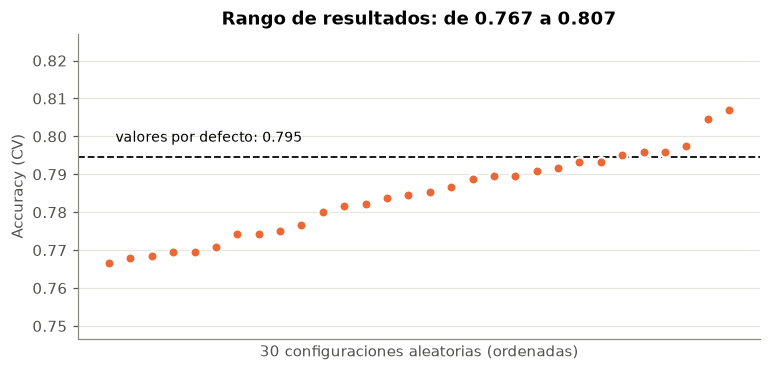

In [13]:
sc = np.sort(rs.cv_results_["mean_test_score"])
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.scatter(range(len(sc)), sc, color=NARANJA, s=45, edgecolor="white", linewidth=1.5, zorder=3)
ax.axhline(score_base, color="#0b0b0b", ls="--", lw=1.2)
ax.text(0.3, score_base + 0.004, f"valores por defecto: {score_base:.3f}", fontsize=9)
ax.set(ylim=(sc.min() - 0.02, sc.max() + 0.02), xticks=[], xlabel="30 configuraciones aleatorias (ordenadas)",
       ylabel="Accuracy (CV)", title=f"Rango de resultados: de {sc.min():.3f} a {sc.max():.3f}")
plt.show()

**Lectura:** una mala combinación cuesta muchos puntos de accuracy; una buena combinación puede superar ligeramente a los valores por defecto. HPO sirve tanto para **ganar** como para **no perder**.

**Ventajas del random search:** funciona bien con muchos hiperparámetros, no le afectan los irrelevantes y es trivial de paralelizar. En la práctica, **30–60 intentos** suelen bastar para una buena solución.

**Límite:** cada intento es **independiente**; no aprende nada de los resultados anteriores.

---
## 5. Estrategia 3 — Successive halving (reducir el costo)

Grid y random search gastan **el mismo cómputo en cada candidato**, aunque sea evidentemente malo. *Successive halving* funciona como un **torneo**:

1. Ronda 1: muchos candidatos, entrenados con **pocos datos** (barato).
2. Se queda con el mejor tercio (`factor=3`) y les da **más datos**.
3. Se repite hasta que quedan pocos candidatos evaluados con **todos los datos**.

El recurso que se reparte suele ser el **número de filas** (`resource="n_samples"`).

Gracias a esto, con un costo similar podemos **evaluar el doble de candidatos** (60 en lugar de 30).

In [14]:
t0 = time.perf_counter()
hs = HalvingRandomSearchCV(base, espacio_random,
                           n_candidates=2 * PRESUPUESTO,       # 60 candidatos iniciales
                           factor=3,                           # en cada ronda sobrevive 1/3
                           resource="n_samples",
                           min_resources=len(X_train) // 9,    # la 1ª ronda usa ~11 % de las filas
                           max_resources=len(X_train),
                           scoring="accuracy", cv=cv3, n_jobs=-1, random_state=SEED)
hs.fit(X_train, y_train)
t_halving = time.perf_counter() - t0

rondas = pd.DataFrame({"ronda": range(1, hs.n_iterations_ + 1),
                       "candidatos": hs.n_candidates_,
                       "filas usadas por candidato": hs.n_resources_})
display(rondas)
print(f"Tiempo: {t_halving:.1f} s  (random search: {t_random:.1f} s)")
print(f"Mejor accuracy (CV, última ronda): {hs.best_score_:.4f}")

,ronda,candidatos,filas usadas por candidato
0,1,60,266
1,2,20,798
2,3,7,2394


Tiempo: 8.6 s  (random search: 8.1 s)
Mejor accuracy (CV, última ronda): 0.8116


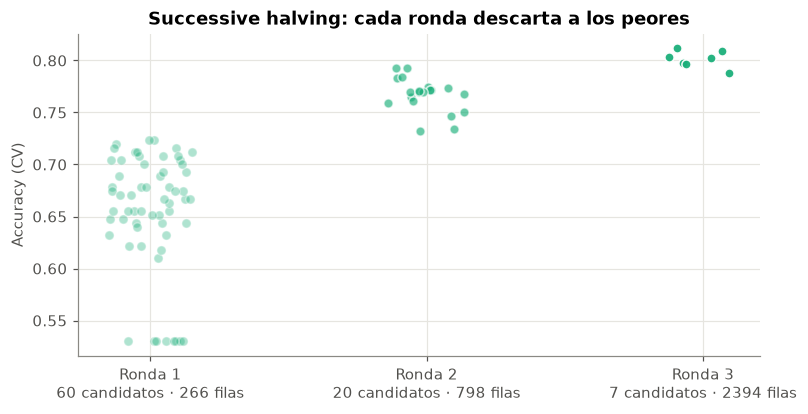

In [15]:
r = pd.DataFrame(hs.cv_results_)
fig, ax = plt.subplots(figsize=(8, 3.8))
for it in sorted(r["iter"].unique()):
    d = r[r["iter"] == it]
    jitter = np.random.default_rng(it).uniform(-0.15, 0.15, len(d))
    ax.scatter(it + 1 + jitter, d["mean_test_score"], s=36, color=AGUAMARINA,
               alpha=0.35 + 0.3 * it, edgecolor="white", linewidth=1)
ax.set(xticks=range(1, hs.n_iterations_ + 1),
       xticklabels=[f"Ronda {i+1}\n{c} candidatos · {n} filas" for i, (c, n) in enumerate(zip(hs.n_candidates_, hs.n_resources_))],
       ylabel="Accuracy (CV)", title="Successive halving: cada ronda descarta a los peores")
plt.show()

**Consejo práctico:** la primera ronda debe tener **muchos candidatos** con el mínimo de datos que todavía permita distinguir buenos de malos (del orden de 1 000 filas suele funcionar). Si la ronda 1 tiene muy pocos datos, se pueden descartar buenos candidatos por puro ruido; en ese caso, bajar `factor` a 2 hace el torneo más gradual.

---
## 6. Estrategia 4 — Optimización bayesiana con Optuna

Hasta ahora ninguna estrategia **aprende** de los resultados anteriores para decidir qué probar después. La optimización bayesiana sí:

1. Construye un **modelo sustituto** (*surrogate*): un modelo barato que estima *"qué score obtendría con esta configuración"* a partir de los intentos ya hechos.
2. Usa una **función de adquisición** para elegir el próximo intento, equilibrando:
   * **Exploración:** probar zonas del espacio donde hay mucha incertidumbre.
   * **Explotación:** probar cerca de donde ya encontramos buenos resultados.
3. Evalúa el modelo real, actualiza el sustituto y repite.

**Optuna** usa por defecto **TPE** (*Tree-structured Parzen Estimator*). La idea simplificada: separa los intentos en "buenos" y "malos", estima qué valores de hiperparámetros son típicos de cada grupo y propone valores que son **probables entre los buenos e improbables entre los malos**.

### Las tres piezas de Optuna

| Pieza | Qué hace |
|---|---|
| `objective(trial)` | Función que **nosotros** escribimos: pide hiperparámetros al `trial`, entrena, valida y devuelve el score |
| `trial.suggest_*` | Define el espacio de búsqueda *dentro* del código (`suggest_float`, `suggest_int`, `suggest_categorical`) |
| `study.optimize(...)` | Ejecuta el bucle: `direction="maximize"` o `"minimize"` y `n_trials` |

In [16]:
def objective(trial):
    params = {
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 1.0, log=True),
        "max_iter":          trial.suggest_int("max_iter", 50, 400),
        "max_leaf_nodes":    trial.suggest_int("max_leaf_nodes", 4, 128),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 5, 100),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-6, 10, log=True),
    }
    modelo = HistGradientBoostingClassifier(early_stopping=False, random_state=0, **params)
    return cross_val_score(modelo, X_train, y_train, cv=cv3, scoring="accuracy", n_jobs=-1).mean()

t0 = time.perf_counter()
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=PRESUPUESTO)
t_optuna = time.perf_counter() - t0

print(f"Tiempo: {t_optuna:.1f} s")
print(f"Mejor accuracy (CV): {study.best_value:.4f}")
pd.Series(study.best_params).round(4)

Tiempo: 34.0 s
Mejor accuracy (CV): 0.8179


learning_rate          0.0103
max_iter             368.0000
max_leaf_nodes        61.0000
min_samples_leaf       8.0000
l2_regularization      0.0001
dtype: float64

Optuna guarda cada intento; podemos inspeccionarlos como una tabla:

In [17]:
study.trials_dataframe()[["number", "value", "params_learning_rate", "params_max_leaf_nodes",
                          "params_min_samples_leaf", "params_max_iter"]].sort_values("value", ascending=False).head(8).round(4)

,number,value,params_learning_rate,params_max_leaf_nodes,params_min_samples_leaf,params_max_iter
15,15,0.8179,0.0103,61,8,368
28,28,0.8158,0.0144,62,5,325
21,21,0.8112,0.0097,64,7,311
22,22,0.8100,0.0055,57,6,354
24,24,0.8100,0.0064,76,17,276
27,27,0.8088,0.0121,48,10,283
25,25,0.8079,0.0065,74,12,400
20,20,0.8067,0.0126,87,26,302


> **Sobre el tiempo:** aquí Optuna ejecuta los intentos uno tras otro (cada uno debe esperar al anterior para aprender de él), mientras que `RandomizedSearchCV` lanza todos los entrenamientos en paralelo. Además, TPE tiende a proponer modelos más grandes. Optuna también puede paralelizar con `study.optimize(..., n_jobs=...)`, a costa de que cada intento aprenda de menos resultados previos.

### ¿Aprende de verdad? Exploración vs. explotación

Comparemos **qué valores de `learning_rate`** propuso cada estrategia a lo largo de los intentos. En random search los valores saltan sin patrón; en Optuna, después de unos intentos iniciales de exploración, las propuestas **se concentran** en la zona prometedora.

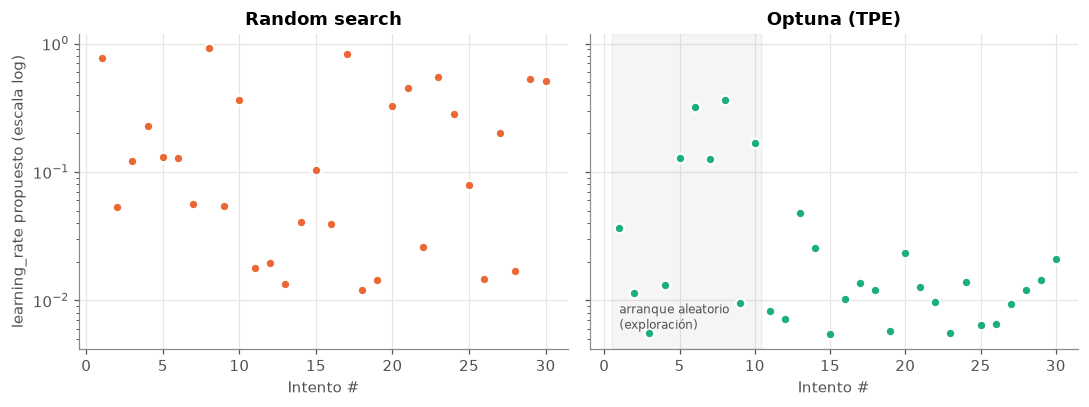

In [18]:
lr_random = np.array([p["learning_rate"] for p in rs.cv_results_["params"]])
lr_optuna = np.array([t.params["learning_rate"] for t in study.trials])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, vals, nombre, color in [(axes[0], lr_random, "Random search", NARANJA),
                                (axes[1], lr_optuna, "Optuna (TPE)", AGUAMARINA)]:
    ax.scatter(range(1, len(vals) + 1), vals, color=color, s=40, edgecolor="white", linewidth=1.5, zorder=3)
    ax.set(yscale="log", xlabel="Intento #", title=nombre)
axes[0].set_ylabel("learning_rate propuesto (escala log)")
axes[1].axvspan(0.5, 10.5, color=GRIS, alpha=0.08)
axes[1].text(1, 0.006, "arranque aleatorio\n(exploración)", fontsize=8, color="#52514e")
plt.tight_layout(); plt.show()

### ¿Qué hiperparámetros importaron más?

Optuna estima la **importancia** de cada hiperparámetro a partir de los intentos. Es útil para explicar el modelo y para reducir el espacio en la siguiente búsqueda.

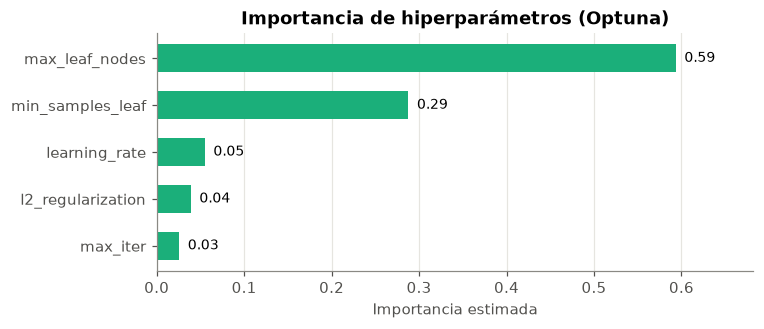

In [18]:
imp = pd.Series(optuna.importance.get_param_importances(study)).sort_values()
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.barh(imp.index, imp.values, color=AGUAMARINA, height=0.6)
for i, v in enumerate(imp.values):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9)
ax.set(xlabel="Importancia estimada", title="Importancia de hiperparámetros (Optuna)", xlim=(0, imp.max() * 1.15))
ax.grid(axis="y", visible=False)
plt.show()

> **Extra de Optuna:** si el estudio se guarda en una base de datos, se puede pausar y retomar:
> ```python
> study = optuna.create_study(storage="sqlite:///hpo.db", study_name="hgb_clase",
>                             direction="maximize", load_if_exists=True)
> ```
> Y la función `objective` es código libre: puede incluir hiperparámetros condicionales (p. ej., solo sugerir `l1_ratio` si el modelo es Elastic Net).

---
## 7. Comparación con el mismo presupuesto

Para ser justos, incluimos también un **grid search** sobre el mismo modelo con 30 combinaciones (5 × 3 × 2). Observen que la rejilla, con el mismo presupuesto, solo alcanza a cubrir **3** de los 5 hiperparámetros.

In [19]:
grid_hgb = {
    "learning_rate":    [0.01, 0.03, 0.1, 0.3, 1.0],
    "max_leaf_nodes":   [8, 31, 127],
    "min_samples_leaf": [10, 50],
}
t0 = time.perf_counter()
gs = GridSearchCV(base, grid_hgb, scoring="accuracy", cv=cv3, n_jobs=-1)
gs.fit(X_train, y_train)
t_grid = time.perf_counter() - t0
print(f"Grid search: {len(gs.cv_results_['params'])} combinaciones | {t_grid:.1f} s | mejor accuracy CV {gs.best_score_:.4f}")

Grid search: 30 combinaciones | 4.1 s | mejor accuracy CV 0.8125


### Curva de convergencia: el mejor score encontrado hasta el intento *n*

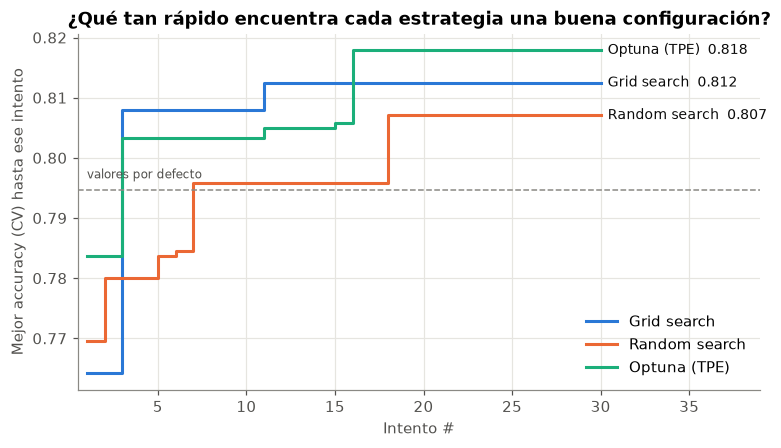

In [20]:
def mejor_hasta_ahora(scores):
    return np.maximum.accumulate(scores)

curvas = {
    "Grid search":   (mejor_hasta_ahora(gs.cv_results_["mean_test_score"]), AZUL),
    "Random search": (mejor_hasta_ahora(rs.cv_results_["mean_test_score"]), NARANJA),
    "Optuna (TPE)":  (mejor_hasta_ahora(np.array([t.value for t in study.trials])), AGUAMARINA),
}
fig, ax = plt.subplots()
for nombre, (c, color) in curvas.items():
    ax.step(range(1, len(c) + 1), c, where="post", color=color, label=nombre)
    ax.text(len(c) + 0.4, c[-1], f"{nombre}  {c[-1]:.3f}", va="center", fontsize=9, color="#0b0b0b")
ax.axhline(score_base, color=GRIS, ls="--", lw=1)
ax.text(1, score_base + 0.002, "valores por defecto", fontsize=8, color="#52514e")
ax.set(xlabel="Intento #", ylabel="Mejor accuracy (CV) hasta ese intento",
       title="¿Qué tan rápido encuentra cada estrategia una buena configuración?", xlim=(0.5, PRESUPUESTO + 9))
ax.legend(loc="lower right", frameon=False)
plt.show()

### Evaluación final en el conjunto de prueba

Ahora sí, y **una sola vez**, sacamos el test de la caja fuerte. Cada modelo se reentrena con **todo** el entrenamiento usando sus mejores hiperparámetros (las búsquedas de scikit-learn lo hacen automáticamente con `refit=True`).

In [21]:
modelo_optuna = HistGradientBoostingClassifier(early_stopping=False, random_state=0, **study.best_params).fit(X_train, y_train)
modelo_base = HistGradientBoostingClassifier(early_stopping=False, random_state=0).fit(X_train, y_train)

resumen = pd.DataFrame([
    ("Valores por defecto", 1,  np.nan,     score_base,       modelo_base.score(X_test, y_test)),
    ("Grid search",        30, t_grid,     gs.best_score_,   gs.score(X_test, y_test)),
    ("Random search",      30, t_random,   rs.best_score_,   rs.score(X_test, y_test)),
    ("Successive halving", 60, t_halving,  hs.best_score_,   hs.score(X_test, y_test)),
    ("Optuna (TPE)",       30, t_optuna,   study.best_value, modelo_optuna.score(X_test, y_test)),
], columns=["Estrategia", "Configuraciones evaluadas", "Tiempo (s)", "Accuracy CV", "Accuracy TEST"])
n_test = len(y_test)
resumen["± IC 95 % (test)"] = 1.96 * np.sqrt(resumen["Accuracy TEST"] * (1 - resumen["Accuracy TEST"]) / n_test)
resumen.round(4)

,Estrategia,Configuraciones evaluadas,Tiempo (s),Accuracy CV,Accuracy TEST,± IC 95 % (test)
0,Valores por defecto,1,NaN,0.7946,0.8267,0.0303
1,Grid search,30,4.1088,0.8125,0.8283,0.0302
2,Random search,30,8.1380,0.8071,0.8350,0.0297
3,Successive halving,60,8.6182,0.8116,0.8183,0.0309
4,Optuna (TPE),30,33.9858,0.8179,0.8300,0.0301


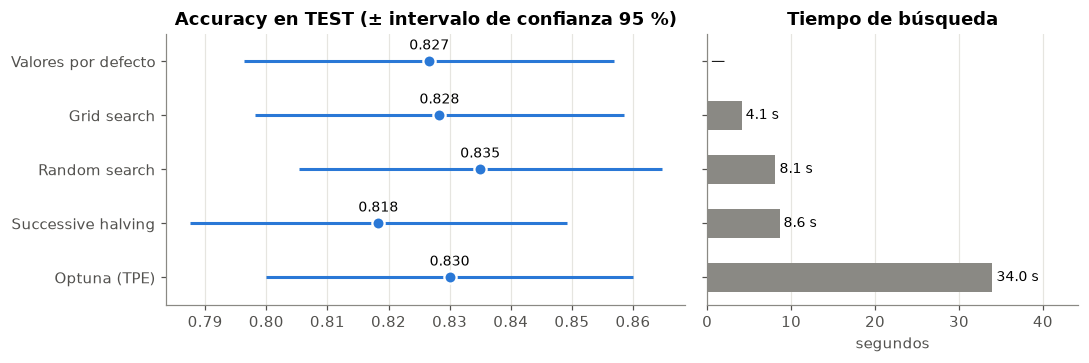

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True, gridspec_kw={"width_ratios": [1.4, 1]})
ypos = np.arange(len(resumen))[::-1]
ax = axes[0]
ax.errorbar(resumen["Accuracy TEST"], ypos, xerr=resumen["± IC 95 % (test)"], fmt="o", color=AZUL,
            ecolor=AZUL, elinewidth=2, capsize=0, markersize=8, markeredgecolor="white", markeredgewidth=1.5)
for yv, v in zip(ypos, resumen["Accuracy TEST"]):
    ax.text(v, yv + 0.22, f"{v:.3f}", ha="center", fontsize=9)
ax.set(yticks=ypos, yticklabels=resumen["Estrategia"], title="Accuracy en TEST (± intervalo de confianza 95 %)")
ax.grid(axis="y", visible=False)
ax = axes[1]
t = resumen["Tiempo (s)"].fillna(0)
ax.barh(ypos, t, color=GRIS, height=0.55)
for yv, v in zip(ypos, t):
    ax.text(v, yv, f" {v:.1f} s" if v else " —", va="center", fontsize=9)
ax.set(title="Tiempo de búsqueda", xlim=(0, t.max() * 1.3), xlabel="segundos")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

**Cómo leer estos resultados (punto clave para la discusión):**

* En validación cruzada todas las estrategias superan a los valores por defecto, pero en test las diferencias suelen ser **pequeñas** y los intervalos de confianza **se traslapan**. Con 600 filas de test, una diferencia de 0.005 son apenas **3 predicciones**. Si en su ejecución los valores por defecto quedan a la par (o incluso por encima), no es un error: es ruido estadístico.
* Por la misma razón, un modelo como `HistGradientBoosting` ya trae valores por defecto razonables; HPO rinde más cuando los valores por defecto están lejos de lo que necesita el problema, o con modelos más sensibles (p. ej., XGBoost con muchos árboles, redes neuronales).
* El score de CV del ganador es **optimista**: elegimos el máximo entre muchos intentos, así que parte de esa ventaja es suerte. Por eso el test es sagrado.
* Lo que sí es robusto: las estrategias que exploran bien (random, halving, bayesiana) **evitan configuraciones malas** y escalan a muchos hiperparámetros; halving lo hace **con menos cómputo por candidato**; la bayesiana llega antes a buenas zonas cuando cada entrenamiento es caro.

---
## 8. ¿Cuándo usar cada estrategia?

| Situación | Estrategia recomendada |
|---|---|
| Pocos hiperparámetros, discretos (modelos lineales, `C`, tipo de penalización) | **Grid search** |
| Muchos hiperparámetros, sin idea de cuáles importan | **Random search** (30–60 intentos) |
| Dataset grande y entrenamiento costoso | **Successive halving** |
| Cada entrenamiento es caro y quiero aprovechar al máximo cada intento; quiero entender qué importó | **Optimización bayesiana (Optuna)** |
| Fase de exploración rápida, aún cambiando features | **Ajuste manual** con reglas empíricas |

### Reglas empíricas para ajuste manual de gradient boosting

* **`learning_rate` y número de árboles van de la mano:** una tasa menor necesita más árboles (Friedman, 1999).
* Si **aumentan la profundidad** de los árboles, **bajen el `learning_rate`** para compensar el riesgo de sobreajuste.
* Consejos de Owen Zhang (Kaggle):
  * Fijar el número de árboles según el tamaño del dataset (100–1 000) y no moverlo; preferir menos.
  * Probar `learning_rate` entre **2/n_árboles y 10/n_árboles** (con 1 000 árboles: 0.002–0.01).
  * Muestreo de filas: 0.5, 0.75, 1.0 · Muestreo de columnas: 0.4, 0.6, 0.8, 1.0 · Profundidad máxima: 4, 6, 8, 10.

### Errores comunes

1. **Ajustar hiperparámetros mirando el test** → el test deja de medir generalización.
2. **Preprocesar fuera del `Pipeline`** (p. ej., escalar todo antes de la CV) → fuga de información.
3. **Espacios de búsqueda lineales** para hiperparámetros que varían en órdenes de magnitud → usar escala log.
4. **Perseguir la cuarta cifra decimal** del score de CV → es ruido; mirar la desviación estándar entre folds.

In [23]:
# La variabilidad entre folds del mejor candidato de random search: ¿cuánto es "ruido"?
i = rs.best_index_
print(f"Mejor candidato random search: {rs.cv_results_['mean_test_score'][i]:.4f} ± {rs.cv_results_['std_test_score'][i]:.4f} (desv. estándar entre folds)")

Mejor candidato random search: 0.8071 ± 0.0048 (desv. estándar entre folds)


---
## 9. Para practicar

1. **Presupuesto.** Cambien `PRESUPUESTO` a 10 y vuelvan a ejecutar las secciones 4–7. ¿Qué estrategia se ve más afectada? ¿Por qué?
2. **Espacio de búsqueda.** En `espacio_random`, cambien `learning_rate` de `loguniform` a `uniform(0.005, 1.0)`. ¿Qué pasa con el mejor score y con los valores que se prueban?
3. **Halving.** Prueben `factor=2` y `min_resources=len(X_train)//4`. ¿Cuántas rondas hay ahora y cuánto tarda?
4. **Optuna.** Agreguen un hiperparámetro nuevo en `objective` (por ejemplo, `max_depth` con `trial.suggest_int("max_depth", 2, 12)`) y revisen si aparece como importante.
5. **Discusión.** Si su mejor modelo obtuvo 0.812 en CV pero 0.795 en test, ¿qué explicaciones hay? ¿Qué harían?

---
**Referencias**
* Bergstra, J. y Bengio, Y. (2012). *Random Search for Hyper-Parameter Optimization*. JMLR.
* Snoek, J., Larochelle, H. y Adams, R. (2012). *Practical Bayesian Optimization of Machine Learning Algorithms*. arXiv:1206.2944.
* Friedman, J. (1999). *Greedy Function Approximation: A Gradient Boosting Machine*.
* Documentación: [scikit-learn — Tuning hyper-parameters](https://scikit-learn.org/stable/modules/grid_search.html) · [Optuna](https://optuna.readthedocs.io/)